# Sales Forecasting Project

## Objective

To build a time series forecasting to predict future sales using historical monthly sales data

## Data Generation and Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create daily dates
dates = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')

# Build realistic sales pattern
trend = np.linspace(100, 300, len(dates))  # upward trend
seasonality = 20 * np.sin(2 * np.pi * dates.dayofyear / 365.25)  # yearly seasonality
weekly = 10 * np.where(dates.dayofweek < 5, 1, 0)  # weekday effect
noise = np.random.normal(0, 8, len(dates))  # random noise

sales = trend + seasonality + weekly + noise

df = pd.DataFrame({
    'Date': dates,
    'Sales': sales
})

df.head()

,Date,Sales
0,2021-01-01,114.317745
1,2021-01-02,99.764662
2,2021-01-03,106.578826
3,2021-01-04,124.107793
4,2021-01-05,110.576157


## Data Preparation

In [2]:
df.to_csv('../data/sales_data.csv', index=False)

In [3]:
df.shape

(1095, 2)

In [4]:
df.describe()

,Date,Sales
count,1095,1095.000000
mean,2022-07-02 00:00:00,207.395981
min,2021-01-01 00:00:00,99.764662
25%,2021-10-01 12:00:00,149.887840
50%,2022-07-02 00:00:00,206.915761
75%,2023-04-01 12:00:00,266.275210
max,2023-12-31 00:00:00,320.756585
std,NaN,56.944014


In [5]:
df.isnull().sum()

Date     0
Sales    0
dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df.head()

,Sales
Date,
2021-01-01,114.317745
2021-01-02,99.764662
2021-01-03,106.578826
2021-01-04,124.107793
2021-01-05,110.576157


## Exploratory Time Series Analysis

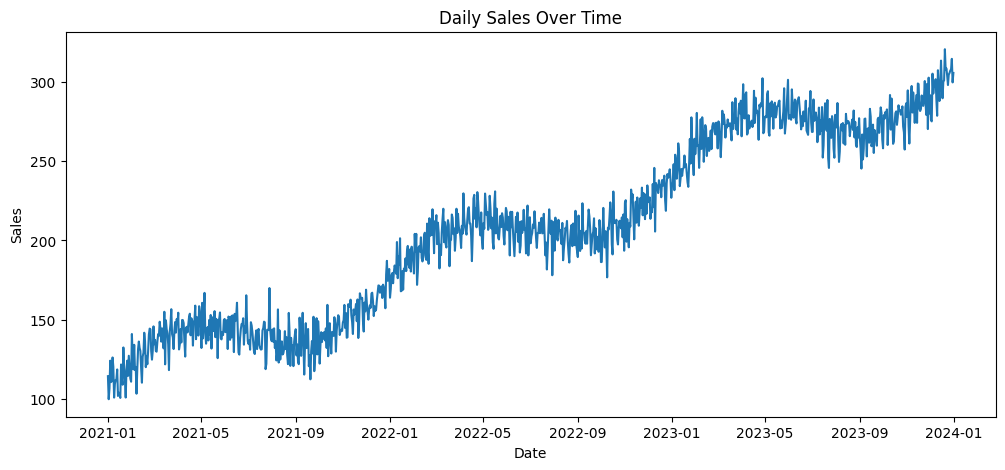

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Sales'])
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

The time series shows an overall upward trend with repeating seasonal fluctuations and short-term variation. This suggests that both trend and seasonality are present in the sales data.

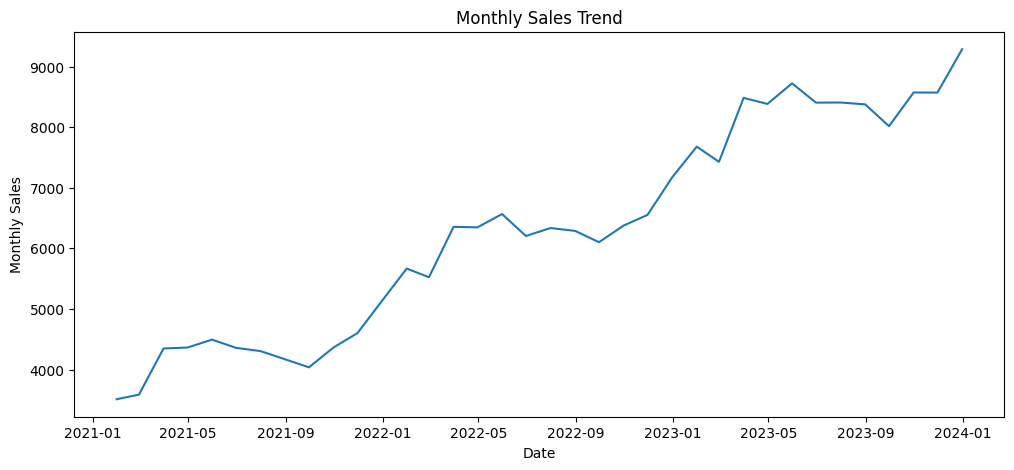

In [9]:
monthly_sales = df['Sales'].resample('ME').sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.show()

Monthly aggregation smooths daily fluctuations and makes the broader sales trend easier to observe. Sales appear to increase over time, indicating a positive long-term trend.

In [10]:
train = monthly_sales[:'2023-06-30']
test = monthly_sales['2023-07-31':]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 30
Test size: 6


## Model Building

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

forecast = model.forecast(len(test))
forecast

2023-07-31    8374.297370
2023-08-31    8282.928050
2023-09-30    8123.782700
2023-10-31    8425.037564
2023-11-30    8630.792390
2023-12-31    9206.502538
Freq: ME, dtype: float64

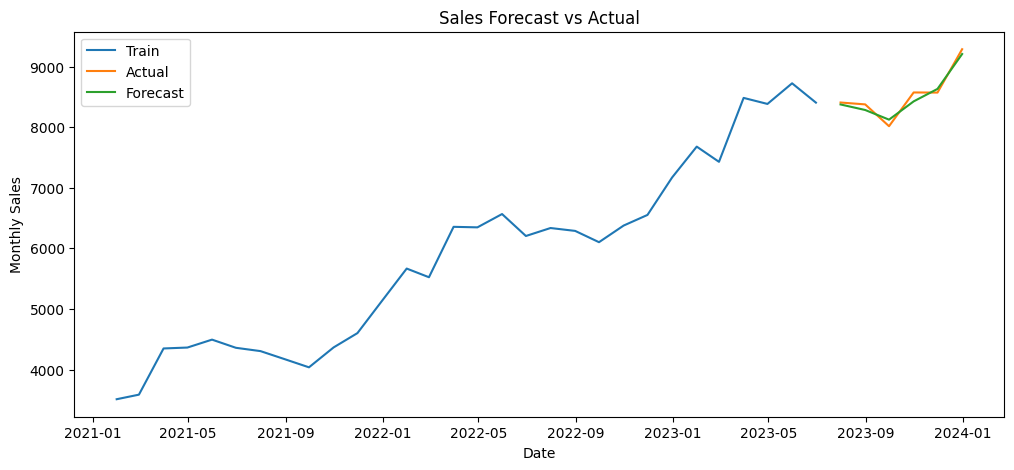

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.title('Sales Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.show()

The forecast follows the general direction of the actual sales values and captures the broader trend and seasonal movement in the data.v

## Model Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 86.55163930587287
RMSE: 93.82287545285392


The forecasting model achieved a Mean Absolute Error (MAE) of approximately 86.6 and a Root Mean Squared Error (RMSE) of approximately 93.8. 

These results indicate that the model is able to capture the overall trend and seasonal patterns in the data, though some deviation from actual values remains. This is expected in real-world forecasting scenarios due to noise and variability in data.

## Future Forecast

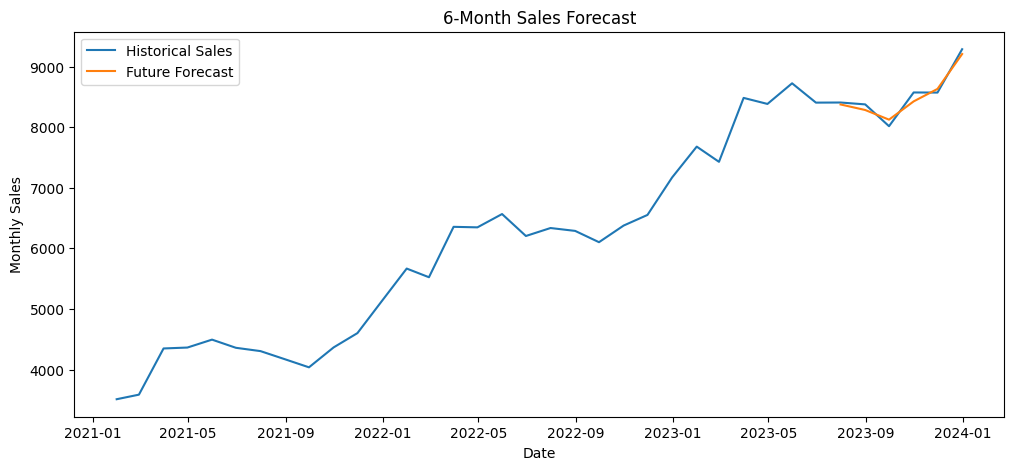

In [14]:
future_forecast = model.forecast(6)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales, label='Historical Sales')
plt.plot(future_forecast.index, future_forecast, label='Future Forecast')
plt.title('6-Month Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.show()

The final forecast extends projected sales into the next six months, which can support planning, budgeting, and business decision-making.

## Conclusion

This project demonstrated a complete time series forecasting workflow, including data preparation, trend analysis, model building, evaluation, and future forecasting. The results show that historical sales patterns can be used to estimate future business performance.